In [3]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
})

BLUE, RED, GREY, AMBER = '#4878CF', '#E84D0E', '#888888', '#F0A500'

In [4]:
# =============================================================================
# PARAMETERS — edit this cell to explore how results change
# =============================================================================

# --- Vendor selection ---
VENDOR_SEED    = 2     # integer ≥ 0 — change to 'consult a different vendor'
PORTFOLIO_SEED = 42   # controls loan characteristics — keep fixed to compare vendors

# --- Flood hazard ---
RETURN_PERIOD = 200   # years — the CFRF/GARP data is for the 1-in-200 year event
# Annual exceedance probability = 1 / RETURN_PERIOD = 0.5%
# This enters the UNCONDITIONAL framing only (see staging section).

# --- Probability framing ---
# "conditional"   — assumes the flood definitely occurs (p = 1.0)
#                   isolates vendor disagreement; natural for stress testing
# "unconditional" — weights stressed PD by the probability the flood occurs
#                   gives the expected ECL uplift; more natural for provisioning
# The notebook computes BOTH and compares them.

# --- LTV-structural model parameters ---
#
# PD_12m(d) = 1 / (1 + exp(-(β₀ + β₁ × LTV(d))))
# where LTV(d) = LTV₀ / (1 - d)
#
# Calibration (β₀=-11.5, β₁=8.0):
#   LTV=0.70 → PD ≈ 0.27%    LTV=0.80 → PD ≈ 0.61%
#   LTV=0.90 → PD ≈ 1.34%    LTV=1.00 → PD ≈ 2.93%
#   LTV=1.10 → PD ≈ 6.30%    LTV=1.30 → PD ≈ 24.97%
#
BETA_0 = -11.5   # logistic intercept — controls baseline PD level
BETA_1 =   8.0   # logistic slope     — controls PD sensitivity to LTV

# LGD(d) = max(1 - (1 - d) * (1 - ω) / LTV₀, 0)
# ω captures foreclosure costs, fire-sale discount, time-to-sale.
# Literature: Qi & Yang (2009) 20–35%; Shleifer & Vishny (1992) theoretical basis.
OMEGA = 0.25     # workout / fire-sale discount (25%)

# --- IFRS 9 staging ---
TAU = 2.0        # SICR threshold: stage if PD_LT(d) / PD_LT_baseline > τ
                 # EBA benchmark = 2.0 (lifetime PD doubles)

# --- Loan portfolio ---
# EAD_i = LTV₀_i × PV₀_i  (structural — not drawn independently)
LTV_LOW,  LTV_HIGH  = 0.60, 0.90   # LTV at origination, Uniform
PV_MU,    PV_SIGMA  = -0.2, 0.5    # log(PV₀) ~ Normal; median ≈ £0.82m
MAT_LOW,  MAT_HIGH  = 5,    25     # loan maturity years, discrete Uniform

# --- Data ---
DATA_PATH = '../../data/raw/cfrf_garp_defended_flood.csv'

In [5]:
# =============================================================================
# DATA LOADING, PORTFOLIO CONSTRUCTION, TRANSMISSION
# =============================================================================

# --- Load and clean CFRF/GARP data ---
df = pd.read_csv(DATA_PATH)
df.rename(columns={'minimim_dr': 'minimum_dr'}, inplace=True)
df = df.dropna(subset=['property_rank']).reset_index(drop=True)
df['property_rank'] = df['property_rank'].astype(int)
n = len(df)

# --- Triangular distribution parameters (vendor uncertainty) ---
tri_a = df['minimum_dr'].values.astype(float)
tri_b = df['maximum_dr'].values.astype(float)
tri_c = np.clip(3.0 * df['mean_dr'].values - tri_a - tri_b, tri_a, tri_b)

# Working DataFrame
results = pd.DataFrame({
    'property_rank': df['property_rank'],
    'd_min':  tri_a,
    'd_mean': df['mean_dr'].values,
    'd_max':  tri_b,
    'd_mode': tri_c,
})

# --- Sample one vendor ---
def triangular_sample(rng, a, b, c):
    """Draw one sample per property from Triangular(a, c, b) via inverse CDF."""
    u    = rng.uniform(size=len(a))
    span = np.where(b > a, b - a, 1.0)
    fc   = np.where(b > a, (c - a) / span, 0.0)
    left  = a + np.sqrt(np.maximum(u, 0) * span * np.maximum(c - a, 0))
    right = b - np.sqrt(np.maximum(1 - u, 0) * span * np.maximum(b - c, 0))
    x     = np.where(u <= fc, left, right)
    return np.where(b > a, np.clip(x, 0, 1), a)   # point mass → return a

vendor_rng = np.random.default_rng(VENDOR_SEED)
d_vendor   = triangular_sample(vendor_rng, tri_a, tri_b, tri_c)
results['d_vendor'] = d_vendor

# --- Construct loan portfolio (LTV-structural) ---
port_rng = np.random.default_rng(PORTFOLIO_SEED)

ltv_0   = port_rng.uniform(LTV_LOW, LTV_HIGH, size=n)          # LTV at origination
pv_0    = stats.lognorm.rvs(                                     # property value (£m)
    s=PV_SIGMA, scale=np.exp(PV_MU), size=n,
    random_state=int(port_rng.integers(2**31))
)
maturity = port_rng.integers(MAT_LOW, MAT_HIGH + 1, size=n)    # years
ead_m    = ltv_0 * pv_0                                         # EAD = LTV₀ × PV₀

# --- Baseline credit risk (d = 0) ---
# PD_12m_base from logistic at LTV₀ (no damage)
pd_12m_base = 1.0 / (1.0 + np.exp(-(BETA_0 + BETA_1 * ltv_0)))
# LGD_base: collateral shortfall at d=0
lgd_base    = np.maximum(1.0 - (1.0 - OMEGA) / ltv_0, 0.0)
pd_lt_base  = 1.0 - (1.0 - pd_12m_base) ** maturity
ecl_base    = pd_12m_base * lgd_base * ead_m

results['ltv_0']        = ltv_0
results['pv_0']         = pv_0
results['ead_m']        = ead_m
results['maturity']     = maturity
results['pd_12m_base']  = pd_12m_base
results['lgd_base']     = lgd_base
results['pd_lt_base']   = pd_lt_base
results['ecl_base']     = ecl_base

# --- Stressed credit risk (LTV-structural transmission) ---
#
# d → PV(d) = PV₀(1-d) → LTV(d) = LTV₀/(1-d)
#          → PD_12m(d) = logistic(β₀ + β₁·LTV(d))
#          → LGD(d)    = max(1 - (1-d)(1-ω)/LTV₀, 0)
#
# Both PD and LGD are driven by the same state variable (current LTV),
# which is the key structural coherence of this model.

d = d_vendor
ltv_str     = ltv_0 / np.maximum(1.0 - d, 1e-6)               # current LTV post-damage
pd_12m_str  = 1.0 / (1.0 + np.exp(-(BETA_0 + BETA_1 * ltv_str)))
lgd_str     = np.maximum(1.0 - (1.0 - d) * (1.0 - OMEGA) / ltv_0, 0.0)
pd_lt_str   = 1.0 - (1.0 - pd_12m_str) ** maturity

results['ltv_str']      = ltv_str
results['pd_12m_str']   = pd_12m_str
results['lgd_str']      = lgd_str
results['pd_lt_str']    = pd_lt_str

# --- IFRS 9 staging ---
p_annual   = 1.0 / RETURN_PERIOD
p_lifetime = 1.0 - (1.0 - p_annual) ** maturity

# Conditional framing (p = 1): flood is certain
sicr_cond  = pd_lt_str / np.maximum(pd_lt_base, 1e-12)
stage_cond = np.where(sicr_cond > TAU, 2, 1)

# Unconditional framing: probability-weighted PDs
pd_12m_uncond = (1.0 - p_annual)  * pd_12m_base + p_annual  * pd_12m_str
pd_lt_uncond  = (1.0 - p_lifetime) * pd_lt_base  + p_lifetime * pd_lt_str

sicr_uncond  = pd_lt_uncond / np.maximum(pd_lt_base, 1e-12)
stage_uncond = np.where(sicr_uncond > TAU, 2, 1)

results['p_lifetime']     = p_lifetime
results['sicr_cond']      = sicr_cond
results['stage_cond']     = stage_cond
results['sicr_uncond']    = sicr_uncond
results['stage_uncond']   = stage_uncond
results['pd_12m_uncond']  = pd_12m_uncond
results['pd_lt_uncond']   = pd_lt_uncond

# --- ECL calculation ---
def compute_ecl(pd_12m, pd_lt, lgd, ead, stage):
    """ECL = PD_12m × LGD × EAD (Stage 1) or PD_LT × LGD × EAD (Stage 2)."""
    return np.where(stage == 2, pd_lt * lgd * ead, pd_12m * lgd * ead)

# Conditional ECL (stressed PDs, stage from conditional SICR)
ecl_cond = compute_ecl(pd_12m_str, pd_lt_str, lgd_str, ead_m, stage_cond)

# Unconditional ECL (probability-adjusted PDs, stage from unconditional SICR)
# Note: lgd_str used in both — if default occurs after a flood, collateral is
# impaired regardless of the probability framing.
ecl_uncond = compute_ecl(pd_12m_uncond, pd_lt_uncond, lgd_str, ead_m, stage_uncond)

results['ecl_cond']   = ecl_cond
results['ecl_uncond'] = ecl_uncond

print(f'Portfolio: {n} loans | Total EAD: £{ead_m.sum():.2f}m')
print(f'Baseline ECL: £{ecl_base.sum():.4f}m  ({ecl_base.sum()/ead_m.sum()*1e4:.1f} bps)')
print(f'Conditional ECL: £{ecl_cond.sum():.4f}m  |  Stage 2: {(stage_cond==2).sum()} loans')
print(f'Unconditional ECL: £{ecl_uncond.sum():.4f}m  |  Stage 2: {(stage_uncond==2).sum()} loans')

Portfolio: 100 loans | Total EAD: £69.31m
Baseline ECL: £0.0265m  (3.8 bps)
Conditional ECL: £4.1917m  |  Stage 2: 39 loans
Unconditional ECL: £0.2288m  |  Stage 2: 5 loans


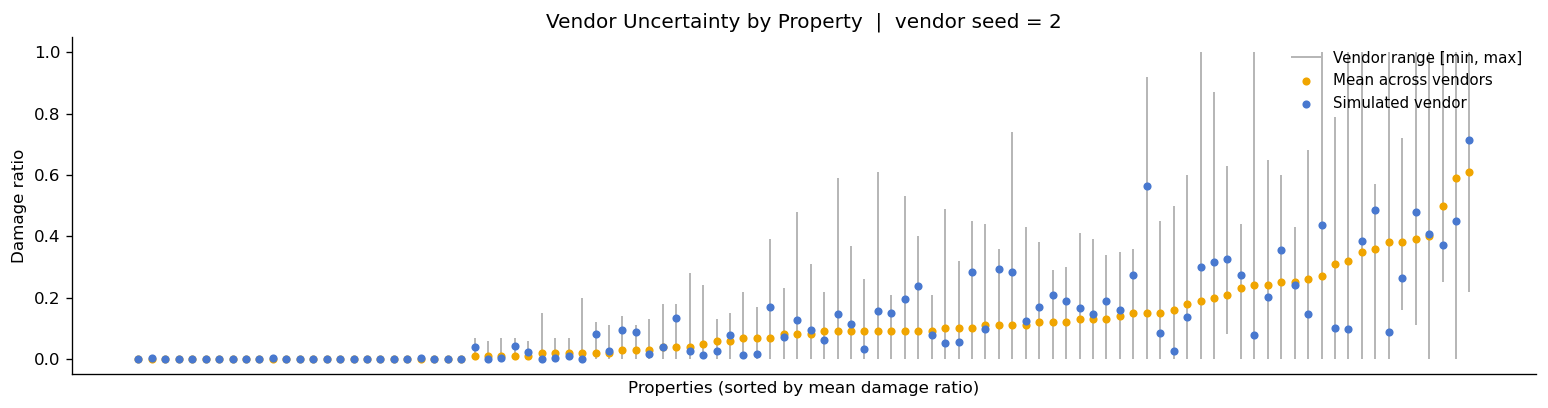

In [6]:
# --- Plot: Vendor range and sampled damage ratios ---
idx      = np.argsort(results['d_mean'].values)
mean_d   = results['d_mean'].values[idx]
min_d    = results['d_min'].values[idx]
max_d    = results['d_max'].values[idx]
vendor_d = results['d_vendor'].values[idx]
x_pos    = np.arange(len(idx))

fig, ax = plt.subplots(figsize=(13, 3.5))
ax.vlines(x_pos, min_d, max_d, color=GREY, linewidth=1.2, alpha=0.6,
          label='Vendor range [min, max]')
ax.scatter(x_pos, mean_d,   color=AMBER, s=15, zorder=3, label='Mean across vendors')
ax.scatter(x_pos, vendor_d, color=BLUE,  s=15, zorder=3, label='Simulated vendor')

ax.set_xlabel('Properties (sorted by mean damage ratio)')
ax.set_ylabel('Damage ratio')
ax.set_title(f'Vendor Uncertainty by Property  |  vendor seed = {VENDOR_SEED}')
ax.set_xticks([])
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

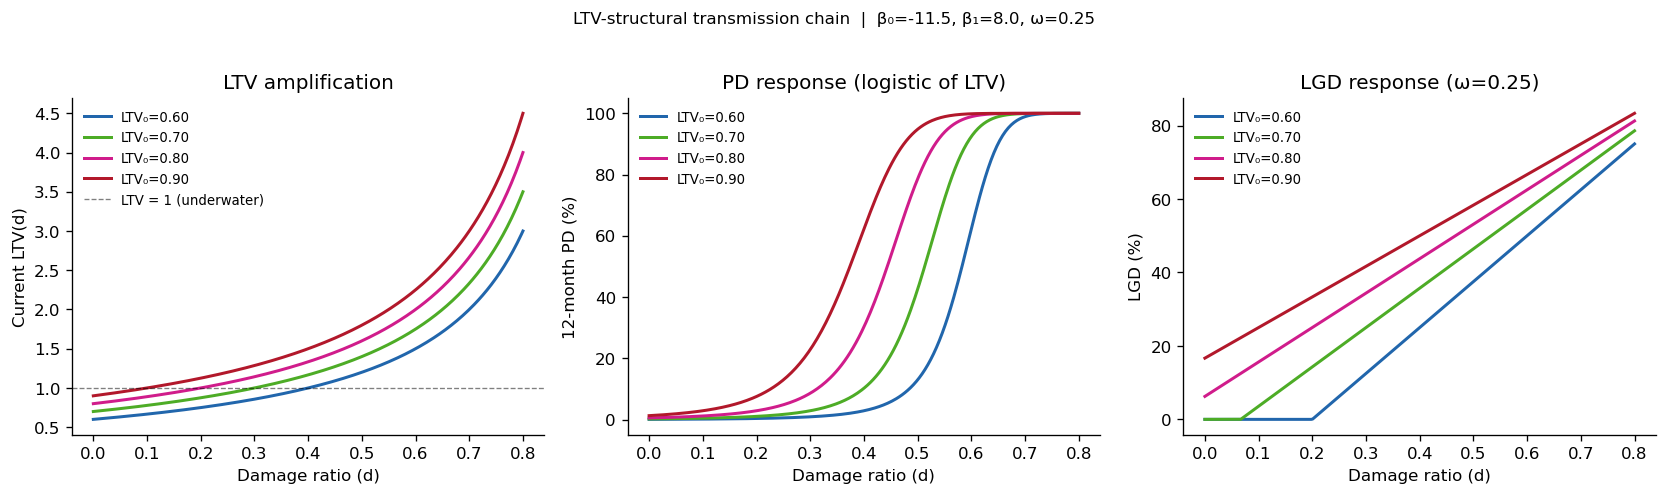

In [7]:
# --- Plot: LTV transmission mechanics ---
# Show how damage propagates through the structural chain for a range of LTV₀ values.

d_grid   = np.linspace(0, 0.8, 300)
ltv_vals = [0.60, 0.70, 0.80, 0.90]
colors_ltv = ['#2166ac', '#4dac26', '#d01c8b', '#b2182b']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Left: LTV(d) = LTV₀ / (1 - d)
for ltv0, col in zip(ltv_vals, colors_ltv):
    ltv_d = ltv0 / np.maximum(1 - d_grid, 1e-6)
    axes[0].plot(d_grid, ltv_d, color=col, linewidth=1.8, label=f'LTV₀={ltv0:.2f}')
axes[0].axhline(1.0, color='black', linewidth=0.8, linestyle='--', alpha=0.5,
                label='LTV = 1 (underwater)')
axes[0].set_xlabel('Damage ratio (d)')
axes[0].set_ylabel('Current LTV(d)')
axes[0].set_title('LTV amplification')
axes[0].legend(frameon=False, fontsize=8)

# Middle: PD_12m(d) = logistic(β₀ + β₁ × LTV(d))
for ltv0, col in zip(ltv_vals, colors_ltv):
    ltv_d = ltv0 / np.maximum(1 - d_grid, 1e-6)
    pd_d  = 1.0 / (1.0 + np.exp(-(BETA_0 + BETA_1 * ltv_d)))
    axes[1].plot(d_grid, pd_d * 100, color=col, linewidth=1.8, label=f'LTV₀={ltv0:.2f}')
pd_base_line = [1.0 / (1.0 + np.exp(-(BETA_0 + BETA_1 * ltv0))) * 100
                for ltv0 in ltv_vals]
axes[1].set_xlabel('Damage ratio (d)')
axes[1].set_ylabel('12-month PD (%)')
axes[1].set_title('PD response (logistic of LTV)')
axes[1].legend(frameon=False, fontsize=8)

# Right: LGD(d) = max(1 - (1-d)(1-ω)/LTV₀, 0)
for ltv0, col in zip(ltv_vals, colors_ltv):
    lgd_d = np.maximum(1.0 - (1.0 - d_grid) * (1.0 - OMEGA) / ltv0, 0.0)
    axes[2].plot(d_grid, lgd_d * 100, color=col, linewidth=1.8, label=f'LTV₀={ltv0:.2f}')
axes[2].set_xlabel('Damage ratio (d)')
axes[2].set_ylabel('LGD (%)')
axes[2].set_title(f'LGD response (ω={OMEGA})')
axes[2].legend(frameon=False, fontsize=8)

fig.suptitle(
    f'LTV-structural transmission chain  |  β₀={BETA_0}, β₁={BETA_1}, ω={OMEGA}',
    fontsize=10, y=1.02
)
plt.tight_layout()
plt.show()

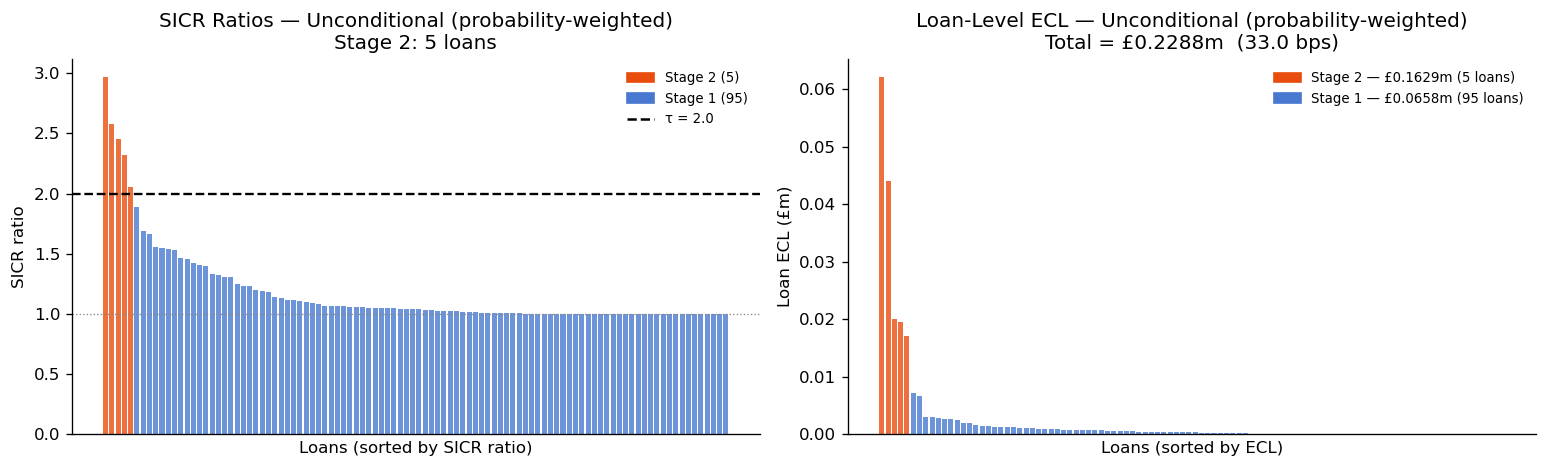

In [8]:
# --- Plot: SICR ratios and ECL (Probability Weighted / Unconditional) ---
prob_weighting = True

if prob_weighting:
    sicr  = results['sicr_uncond'].values
    ecl   = results['ecl_uncond'].values
    stage = results['stage_uncond'].values
    title = 'Unconditional (probability-weighted)'
else:
    sicr  = results['sicr_cond'].values
    ecl   = results['ecl_cond'].values
    stage = results['stage_cond'].values
    title = 'Conditional (flood certain)'

sicr_order = np.argsort(sicr)[::-1]
ecl_order  = np.argsort(ecl)[::-1]
n_s2       = (stage == 2).sum()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# SICR
sicr_colors = [RED if s == 2 else BLUE for s in stage[sicr_order]]
axes[0].bar(np.arange(n), sicr[sicr_order], color=sicr_colors, width=0.8, alpha=0.8)
axes[0].axhline(TAU, color='black', linewidth=1.4, linestyle='--')
axes[0].axhline(1.0, color=GREY, linewidth=0.8, linestyle=':')
axes[0].set_xlabel('Loans (sorted by SICR ratio)')
axes[0].set_ylabel('SICR ratio')
axes[0].set_title(f'SICR Ratios — {title}\nStage 2: {n_s2} loans')
axes[0].set_xticks([])
axes[0].legend(
    handles=[
        mpatches.Patch(color=RED,  label=f'Stage 2 ({n_s2})'),
        mpatches.Patch(color=BLUE, label=f'Stage 1 ({n - n_s2})'),
        plt.Line2D([0],[0], color='black', linestyle='--', label=f'τ = {TAU}'),
    ],
    frameon=False, fontsize=8
)

# ECL
ecl_colors = [RED if s == 2 else BLUE for s in stage[ecl_order]]
axes[1].bar(np.arange(n), ecl[ecl_order], color=ecl_colors, width=0.8, alpha=0.8)
ecl_s1 = ecl[stage == 1].sum()
ecl_s2 = ecl[stage == 2].sum()
axes[1].set_xlabel('Loans (sorted by ECL)')
axes[1].set_ylabel('Loan ECL (£m)')
axes[1].set_title(
    f'Loan-Level ECL — {title}\n'
    f'Total = £{ecl.sum():.4f}m  ({ecl.sum()/ead_m.sum()*1e4:.1f} bps)'
)
axes[1].set_xticks([])
axes[1].legend(
    handles=[
        mpatches.Patch(color=RED,  label=f'Stage 2 — £{ecl_s2:.4f}m ({n_s2} loans)'),
        mpatches.Patch(color=BLUE, label=f'Stage 1 — £{ecl_s1:.4f}m ({n - n_s2} loans)'),
    ],
    frameon=False, fontsize=8
)

plt.tight_layout()
plt.show()

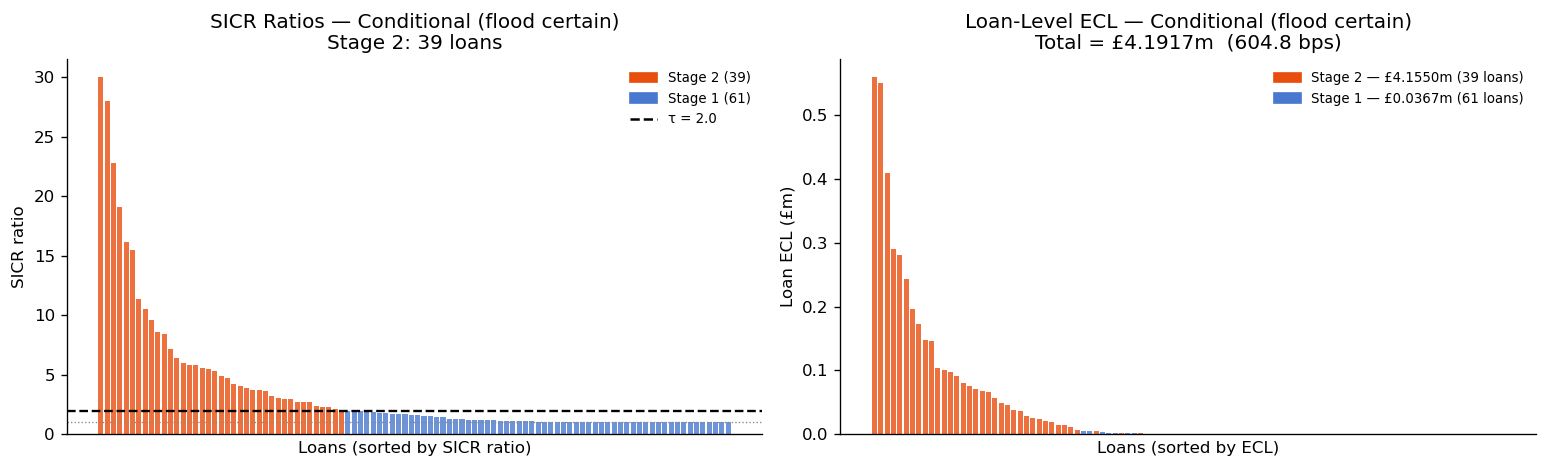

In [9]:
# --- Plot: SICR ratios and ECL (Conditional / Non-probability-weighted) ---
prob_weighting = False

if prob_weighting:
    sicr  = results['sicr_uncond'].values
    ecl   = results['ecl_uncond'].values
    stage = results['stage_uncond'].values
    title = 'Unconditional (probability-weighted)'
else:
    sicr  = results['sicr_cond'].values
    ecl   = results['ecl_cond'].values
    stage = results['stage_cond'].values
    title = 'Conditional (flood certain)'

sicr_order = np.argsort(sicr)[::-1]
ecl_order  = np.argsort(ecl)[::-1]
n_s2       = (stage == 2).sum()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# SICR
sicr_colors = [RED if s == 2 else BLUE for s in stage[sicr_order]]
axes[0].bar(np.arange(n), sicr[sicr_order], color=sicr_colors, width=0.8, alpha=0.8)
axes[0].axhline(TAU, color='black', linewidth=1.4, linestyle='--')
axes[0].axhline(1.0, color=GREY, linewidth=0.8, linestyle=':')
axes[0].set_xlabel('Loans (sorted by SICR ratio)')
axes[0].set_ylabel('SICR ratio')
axes[0].set_title(f'SICR Ratios — {title}\nStage 2: {n_s2} loans')
axes[0].set_xticks([])
axes[0].legend(
    handles=[
        mpatches.Patch(color=RED,  label=f'Stage 2 ({n_s2})'),
        mpatches.Patch(color=BLUE, label=f'Stage 1 ({n - n_s2})'),
        plt.Line2D([0],[0], color='black', linestyle='--', label=f'τ = {TAU}'),
    ],
    frameon=False, fontsize=8
)

# ECL
ecl_colors = [RED if s == 2 else BLUE for s in stage[ecl_order]]
axes[1].bar(np.arange(n), ecl[ecl_order], color=ecl_colors, width=0.8, alpha=0.8)
ecl_s1 = ecl[stage == 1].sum()
ecl_s2 = ecl[stage == 2].sum()
axes[1].set_xlabel('Loans (sorted by ECL)')
axes[1].set_ylabel('Loan ECL (£m)')
axes[1].set_title(
    f'Loan-Level ECL — {title}\n'
    f'Total = £{ecl.sum():.4f}m  ({ecl.sum()/ead_m.sum()*1e4:.1f} bps)'
)
axes[1].set_xticks([])
axes[1].legend(
    handles=[
        mpatches.Patch(color=RED,  label=f'Stage 2 — £{ecl_s2:.4f}m ({n_s2} loans)'),
        mpatches.Patch(color=BLUE, label=f'Stage 1 — £{ecl_s1:.4f}m ({n - n_s2} loans)'),
    ],
    frameon=False, fontsize=8
)

plt.tight_layout()
plt.show()

In [10]:
# =============================================================================
# Helper: run the full LTV-structural ECL calculation for one parameter set
# =============================================================================

def run_one(
    vendor_seed    = None,
    portfolio_seed = None,
    beta_0         = None,
    beta_1         = None,
    omega          = None,
    tau            = None,
    return_period  = None,
):
    """
    Run the full LTV-structural ECL calculation for one parameter combination.

    All arguments default to the notebook-level parameter values, so you can
    call run_one(vendor_seed=5) to change only the vendor and keep everything
    else fixed.

    Returns a dict with portfolio-level summary statistics.
    """
    vs  = VENDOR_SEED    if vendor_seed    is None else vendor_seed
    ps  = PORTFOLIO_SEED if portfolio_seed is None else portfolio_seed
    b0  = BETA_0         if beta_0         is None else beta_0
    b1  = BETA_1         if beta_1         is None else beta_1
    om  = OMEGA          if omega          is None else omega
    t   = TAU            if tau            is None else tau
    rp  = RETURN_PERIOD  if return_period  is None else return_period

    # Vendor draw
    d = triangular_sample(np.random.default_rng(vs), tri_a, tri_b, tri_c)

    # Loan portfolio
    rng  = np.random.default_rng(ps)
    ltv0 = rng.uniform(LTV_LOW, LTV_HIGH, size=n)
    pv0  = stats.lognorm.rvs(
        s=PV_SIGMA, scale=np.exp(PV_MU), size=n,
        random_state=int(rng.integers(2**31))
    )
    mat  = rng.integers(MAT_LOW, MAT_HIGH + 1, size=n)
    ead  = ltv0 * pv0

    # Baseline (d = 0)
    pd12_b = 1.0 / (1.0 + np.exp(-(b0 + b1 * ltv0)))
    lgd_b  = np.maximum(1.0 - (1.0 - om) / ltv0, 0.0)
    pdlt_b = 1.0 - (1.0 - pd12_b) ** mat
    ecl_b  = pd12_b * lgd_b * ead

    # Stressed (LTV-structural)
    ltv_s  = ltv0 / np.maximum(1.0 - d, 1e-6)
    pd12_s = 1.0 / (1.0 + np.exp(-(b0 + b1 * ltv_s)))
    lgd_s  = np.maximum(1.0 - (1.0 - d) * (1.0 - om) / ltv0, 0.0)
    pdlt_s = 1.0 - (1.0 - pd12_s) ** mat

    # Conditional staging & ECL
    sicr_c  = pdlt_s / np.maximum(pdlt_b, 1e-12)
    stage_c = np.where(sicr_c > t, 2, 1)
    ecl_c   = np.where(stage_c == 2, pdlt_s * lgd_s * ead, pd12_s * lgd_s * ead)

    # Unconditional staging & ECL
    p_a    = 1.0 / rp
    p_lt   = 1.0 - (1.0 - p_a) ** mat
    pd12_u = (1.0 - p_a)  * pd12_b + p_a  * pd12_s
    pdlt_u = (1.0 - p_lt) * pdlt_b + p_lt * pdlt_s
    sicr_u  = pdlt_u / np.maximum(pdlt_b, 1e-12)
    stage_u = np.where(sicr_u > t, 2, 1)
    ecl_u   = np.where(stage_u == 2, pdlt_u * lgd_s * ead, pd12_u * lgd_s * ead)

    ead_tot = ead.sum()
    return {
        'ecl_base':       ecl_b.sum(),
        'ecl_cond':       ecl_c.sum(),
        'ecl_uncond':     ecl_u.sum(),
        'ecl_cond_bps':   ecl_c.sum() / ead_tot * 1e4,
        'ecl_uncond_bps': ecl_u.sum() / ead_tot * 1e4,
        'n_s2_cond':      int((stage_c == 2).sum()),
        'n_s2_uncond':    int((stage_u == 2).sum()),
        'ead_total':      ead_tot,
    }


def _bar_width(x):
    """Sensible bar width for sensitivity sweeps."""
    if len(x) < 2:
        return 0.4
    gaps = np.diff(np.sort(x))
    return float(gaps.min()) * 0.6 if gaps.min() > 0 else 0.4


# Quick check — should match the main calculation above
ref = run_one()
print(f'run_one() check — conditional ECL: £{ref["ecl_cond"]:.4f}m, '
      f'Stage 2: {ref["n_s2_cond"]} loans')

run_one() check — conditional ECL: £4.1917m, Stage 2: 39 loans


Sensitivity sweep: vendor_seed
Fixed parameters: β₀=-11.5, β₁=8.0, ω=0.25, τ=2.0, RP=200, vendor=2, portfolio=42

 vendor_seed  ECL_cond (£m)  ECL_cond (bps)  Stage2_cond  ECL_uncond (£m)  ECL_uncond (bps)  Stage2_uncond
           0          6.422         926.532           32            0.397            57.233              8
           1          6.559         946.283           43            0.329            47.501              5
           2          4.192         604.784           39            0.229            33.006              5
           3          5.077         732.500           41            0.267            38.517              6
           4          7.785        1123.200           37            0.500            72.206             10
           5          3.934         567.554           35            0.233            33.587              4
           6          6.207         895.509           41            0.266            38.427              5
           7          5.725   

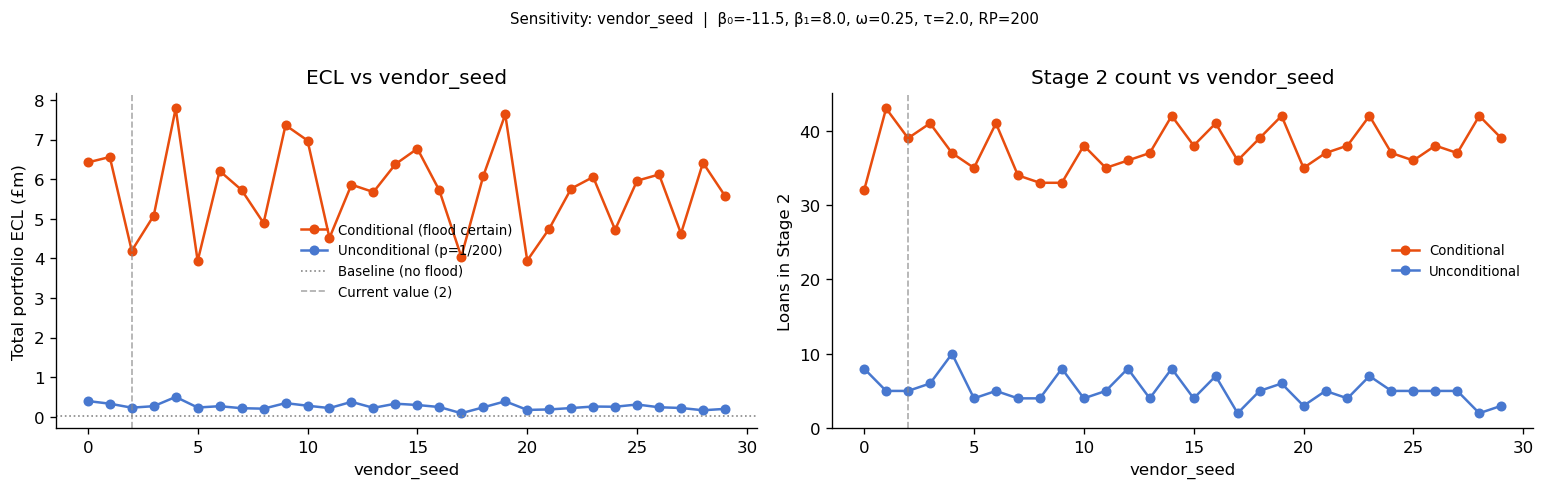

In [11]:
# =============================================================================
# SENSITIVITY ANALYSIS
# Change SWEEP_PARAM and SWEEP_VALUES to explore any parameter.
# Everything else stays fixed at the notebook-level parameter values.
# =============================================================================

SWEEP_PARAM  = 'vendor_seed'          # which parameter to vary
SWEEP_VALUES = list(range(0, 30))   # values to loop over

# Other ready-to-use configurations — uncomment one:
# SWEEP_PARAM = 'portfolio_seed';  SWEEP_VALUES = list(range(0, 30))
# SWEEP_PARAM = 'beta_0';          SWEEP_VALUES = [-13.0, -12.0, -11.5, -11.0, -10.5, -10.0]
# SWEEP_PARAM = 'beta_1';          SWEEP_VALUES = [6.0, 7.0, 8.0, 9.0, 10.0]
# SWEEP_PARAM = 'omega';           SWEEP_VALUES = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35]
# SWEEP_PARAM = 'tau';             SWEEP_VALUES = [1.25, 1.5, 1.75, 2.0, 2.5, 3.0]
# SWEEP_PARAM = 'return_period';   SWEEP_VALUES = [20, 50, 100, 200, 500, 1000]

# --- Run sweep ---
rows = []
for val in SWEEP_VALUES:
    res = run_one(**{SWEEP_PARAM: val})
    rows.append({'param_value': val, **res})

sweep = pd.DataFrame(rows)

# --- Summary table ---
print(f'Sensitivity sweep: {SWEEP_PARAM}')
print(f'Fixed parameters: β₀={BETA_0}, β₁={BETA_1}, ω={OMEGA}, τ={TAU}, '
      f'RP={RETURN_PERIOD}, vendor={VENDOR_SEED}, portfolio={PORTFOLIO_SEED}')
print()
print(sweep[['param_value', 'ecl_cond', 'ecl_cond_bps', 'n_s2_cond',
             'ecl_uncond', 'ecl_uncond_bps', 'n_s2_uncond']]
      .rename(columns={
          'param_value':    SWEEP_PARAM,
          'ecl_cond':       'ECL_cond (£m)',
          'ecl_cond_bps':   'ECL_cond (bps)',
          'n_s2_cond':      'Stage2_cond',
          'ecl_uncond':     'ECL_uncond (£m)',
          'ecl_uncond_bps': 'ECL_uncond (bps)',
          'n_s2_uncond':    'Stage2_uncond',
      })
      .to_string(index=False, float_format=lambda x: f'{x:.3f}'))

# --- Plot ---
current_val = {
    'vendor_seed': VENDOR_SEED, 'portfolio_seed': PORTFOLIO_SEED,
    'beta_0': BETA_0, 'beta_1': BETA_1, 'omega': OMEGA,
    'tau': TAU, 'return_period': RETURN_PERIOD,
}.get(SWEEP_PARAM)

x = sweep['param_value'].values
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: ECL vs parameter
ax = axes[0]
ax.plot(x, sweep['ecl_cond'],   color=RED,  marker='o', markersize=5,
        linewidth=1.5, label='Conditional (flood certain)')
ax.plot(x, sweep['ecl_uncond'], color=BLUE, marker='o', markersize=5,
        linewidth=1.5, label=f'Unconditional (p=1/{RETURN_PERIOD})')
ax.axhline(sweep['ecl_base'].iloc[0], color=GREY, linewidth=1.0,
           linestyle=':', label='Baseline (no flood)')
if current_val is not None and current_val in list(SWEEP_VALUES):
    ax.axvline(current_val, color=GREY, linewidth=1.0, linestyle='--',
               alpha=0.7, label=f'Current value ({current_val})')
ax.set_xlabel(SWEEP_PARAM)
ax.set_ylabel('Total portfolio ECL (£m)')
ax.set_title(f'ECL vs {SWEEP_PARAM}')
ax.legend(frameon=False, fontsize=8)

# Right: Stage 2 loan count vs parameter
ax2 = axes[1]
ax2.plot(x, sweep['n_s2_cond'],   color=RED,  marker='o', markersize=5,
         linewidth=1.5, label='Conditional')
ax2.plot(x, sweep['n_s2_uncond'], color=BLUE, marker='o', markersize=5,
         linewidth=1.5, label='Unconditional')
if current_val is not None and current_val in list(SWEEP_VALUES):
    ax2.axvline(current_val, color=GREY, linewidth=1.0, linestyle='--', alpha=0.7)
ax2.set_xlabel(SWEEP_PARAM)
ax2.set_ylabel('Loans in Stage 2')
ax2.set_title(f'Stage 2 count vs {SWEEP_PARAM}')
ax2.legend(frameon=False, fontsize=8)

fig.suptitle(
    f'Sensitivity: {SWEEP_PARAM}  |  '
    f'β₀={BETA_0}, β₁={BETA_1}, ω={OMEGA}, τ={TAU}, RP={RETURN_PERIOD}',
    fontsize=9, y=1.01
)
plt.tight_layout()
plt.show()

---
## Global Sensitivity Analysis — Sobol Indices

The one-at-a-time sweep above holds all other parameters fixed, so it misses
**interaction effects**: e.g. does β₁ matter more when τ is low?

**Variance-based (Sobol) GSA** answers this properly. It samples all parameters
simultaneously across their full ranges and decomposes the variance of portfolio
ECL into contributions from each parameter:

| Index | Meaning |
|---|---|
| **S1** (first-order) | Fraction of ECL variance explained by this parameter *alone* |
| **ST** (total-order) | Fraction including all interactions with other parameters |
| **ST − S1** | Variance attributable purely to interactions |

Parameters varied:

| Parameter | Range | Represents |
|---|---|---|
| `beta_0` | [−13.0, −10.0] | Logistic intercept — baseline PD level |
| `beta_1` | [6.0, 10.0] | Logistic slope — PD sensitivity to LTV |
| `omega` | [0.15, 0.35] | Workout / fire-sale discount |
| `tau` | [1.5, 2.5] | SICR staging threshold |
| `vendor_seed` | [0, 999] | Which vendor the FI happens to use |
| `portfolio_seed` | [0, 999] | Loan book composition uncertainty |

`return_period` is excluded from the conditional ECL GSA (flood is assumed certain
regardless of RP in that framing). It matters for the unconditional framing.

In [14]:
from SALib.sample import sobol as sobol_sample
from SALib.analyze import sobol as sobol_analyze

# =============================================================================
# GSA CONFIGURATION
# =============================================================================

GSA_N = 1024   # Saltelli base sample size; total model runs = N × (2k + 2)
               # k=6 parameters → 14,336 runs at N=1024

GSA_PROBLEM = {
    'num_vars': 6,
    'names':  ['beta_0', 'beta_1', 'omega', 'tau', 'vendor_seed', 'portfolio_seed'],
    'bounds': [
        [-13.0, -10.0],   # beta_0:         plausible range for logistic intercept
        [  6.0,  10.0],   # beta_1:         plausible range for logistic slope
        [  0.15,  0.35],  # omega:           workout discount range from literature
        [  1,   3],   # tau:             from lenient (1.5) to conservative (2.5)
        [  0,    999],    # vendor_seed:     1000 hypothetical vendors
        [  0,    999],    # portfolio_seed:  1000 hypothetical loan books
    ],
}

# =============================================================================
# Run the model across all Saltelli samples
# =============================================================================

param_values = sobol_sample.sample(GSA_PROBLEM, GSA_N, calc_second_order=False)
print(f'Running {len(param_values):,} model evaluations '
      f'({GSA_N} × (2×{GSA_PROBLEM["num_vars"]}+2))...')

Y_cond   = np.zeros(len(param_values))
Y_uncond = np.zeros(len(param_values))

for i, p in enumerate(param_values):
    res = run_one(
        beta_0         = float(p[0]),
        beta_1         = float(p[1]),
        omega          = float(p[2]),
        tau            = float(p[3]),
        vendor_seed    = int(p[4]),
        portfolio_seed = int(p[5]),
    )
    Y_cond[i]   = res['ecl_cond']
    Y_uncond[i] = res['ecl_uncond']

print(f'Done.  ECL_cond:   mean=£{Y_cond.mean():.3f}m  std=£{Y_cond.std():.3f}m')
print(f'       ECL_uncond: mean=£{Y_uncond.mean():.3f}m  std=£{Y_uncond.std():.3f}m')

# =============================================================================
# Compute Sobol indices
# =============================================================================

Si_cond   = sobol_analyze.analyze(GSA_PROBLEM, Y_cond,   calc_second_order=False,
                                   print_to_console=False)
Si_uncond = sobol_analyze.analyze(GSA_PROBLEM, Y_uncond, calc_second_order=False,
                                   print_to_console=False)

names = GSA_PROBLEM['names']
gsa_df = pd.DataFrame({
    'Parameter':    names,
    'S1_cond':      Si_cond['S1'],
    'S1_cond_CI':   Si_cond['S1_conf'],
    'ST_cond':      Si_cond['ST'],
    'ST_cond_CI':   Si_cond['ST_conf'],
    'S1_uncond':    Si_uncond['S1'],
    'S1_uncond_CI': Si_uncond['S1_conf'],
    'ST_uncond':    Si_uncond['ST'],
    'ST_uncond_CI': Si_uncond['ST_conf'],
})

print('\nSobol indices — Conditional ECL (flood certain)')
print(gsa_df[['Parameter','S1_cond','S1_cond_CI','ST_cond','ST_cond_CI']]
      .to_string(index=False, float_format=lambda x: f'{x:.3f}'))
print('\nSobol indices — Unconditional ECL (probability-weighted)')
print(gsa_df[['Parameter','S1_uncond','S1_uncond_CI','ST_uncond','ST_uncond_CI']]
      .to_string(index=False, float_format=lambda x: f'{x:.3f}'))

Running 8,192 model evaluations (1024 × (2×6+2))...
Done.  ECL_cond:   mean=£5.555m  std=£1.924m
       ECL_uncond: mean=£0.458m  std=£0.430m

Sobol indices — Conditional ECL (flood certain)
     Parameter  S1_cond  S1_cond_CI  ST_cond  ST_cond_CI
        beta_0    0.113       0.037    0.169       0.022
        beta_1    0.315       0.050    0.384       0.043
         omega    0.105       0.029    0.142       0.017
           tau    0.030       0.019    0.051       0.011
   vendor_seed    0.170       0.046    0.244       0.027
portfolio_seed    0.132       0.036    0.217       0.023

Sobol indices — Unconditional ECL (probability-weighted)
     Parameter  S1_uncond  S1_uncond_CI  ST_uncond  ST_uncond_CI
        beta_0      0.028         0.046      0.274         0.080
        beta_1      0.065         0.047      0.319         0.095
         omega      0.024         0.022      0.071         0.020
           tau      0.463         0.133      0.790         0.180
   vendor_seed      0.024  

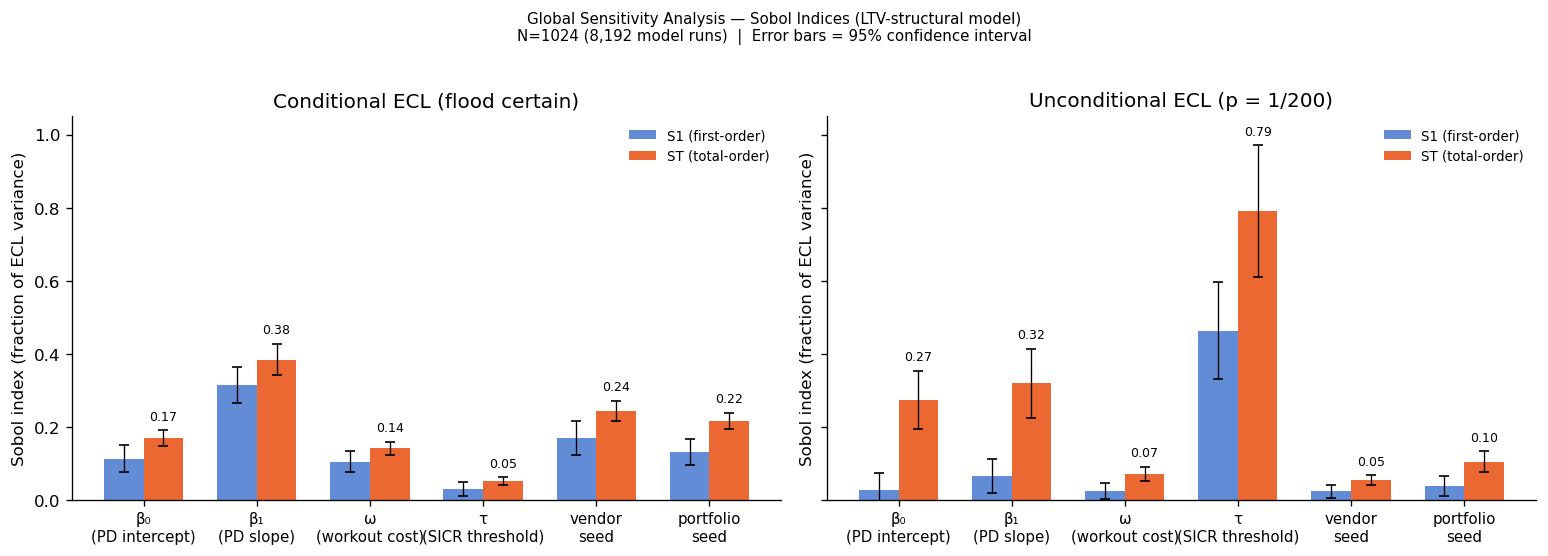

Interpretation guide:
  S1 ≈ ST       → parameter acts mostly independently (no strong interactions)
  ST >> S1      → parameter is important mainly through interactions
  S1 ≈ ST ≈ 0   → parameter has negligible influence on ECL variance
  ΣST > 1       → interactions present in the model (expected here)

Key LTV-structural interpretation:
  If vendor_seed has meaningful ST, vendor selection contributes to ECL
  variance alongside structural model parameter uncertainty.
  If β₁ dominates: PD sensitivity to LTV changes is the key driver.
  If τ dominates: the SICR staging discontinuity is the key mechanism.


In [15]:
# =============================================================================
# Plot Sobol indices — conditional and unconditional side by side
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)

bar_w  = 0.35
x      = np.arange(len(names))
labels = [
    'β₀\n(PD intercept)', 'β₁\n(PD slope)', 'ω\n(workout cost)',
    'τ\n(SICR threshold)', 'vendor\nseed', 'portfolio\nseed'
]

for ax, s1, s1_ci, st, st_ci, title in [
    (axes[0],
     Si_cond['S1'],   Si_cond['S1_conf'],
     Si_cond['ST'],   Si_cond['ST_conf'],
     'Conditional ECL (flood certain)'),
    (axes[1],
     Si_uncond['S1'], Si_uncond['S1_conf'],
     Si_uncond['ST'], Si_uncond['ST_conf'],
     f'Unconditional ECL (p = 1/{RETURN_PERIOD})'),
]:
    ax.bar(x - bar_w/2, np.maximum(s1, 0), bar_w,
           color=BLUE, alpha=0.85, label='S1 (first-order)',
           yerr=s1_ci, capsize=3, error_kw=dict(linewidth=0.8))
    ax.bar(x + bar_w/2, np.maximum(st, 0), bar_w,
           color=RED,  alpha=0.85, label='ST (total-order)',
           yerr=st_ci, capsize=3, error_kw=dict(linewidth=0.8))

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylabel('Sobol index (fraction of ECL variance)')
    ax.set_ylim(0, 1.05)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_title(title)
    ax.legend(frameon=False, fontsize=8)

    for i, (s1v, stv) in enumerate(zip(s1, st)):
        if stv > 0.02:
            ax.text(i + bar_w/2, min(stv + st_ci[i] + 0.02, 1.0),
                    f'{stv:.2f}', ha='center', va='bottom', fontsize=7.5)

fig.suptitle(
    f'Global Sensitivity Analysis — Sobol Indices (LTV-structural model)\n'
    f'N={GSA_N} ({len(param_values):,} model runs)  |  '
    f'Error bars = 95% confidence interval',
    fontsize=9, y=1.02
)
plt.tight_layout()
plt.show()

print('Interpretation guide:')
print('  S1 ≈ ST       → parameter acts mostly independently (no strong interactions)')
print('  ST >> S1      → parameter is important mainly through interactions')
print('  S1 ≈ ST ≈ 0   → parameter has negligible influence on ECL variance')
print('  ΣST > 1       → interactions present in the model (expected here)')
print()
print('Key LTV-structural interpretation:')
print('  If vendor_seed has meaningful ST, vendor selection contributes to ECL')
print('  variance alongside structural model parameter uncertainty.')
print('  If β₁ dominates: PD sensitivity to LTV changes is the key driver.')
print('  If τ dominates: the SICR staging discontinuity is the key mechanism.')